In [1]:
import tensorflow as tf

from sklearn import metrics 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

from tqdm.notebook import tqdm
import random
import warnings

warnings.filterwarnings("ignore")

In [2]:
(trainX, trainY), (testX, testY) = tf.keras.datasets.fashion_mnist.load_data()

In [3]:
trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
testX = testX.reshape((testX.shape[0], 28, 28, 1))

In [4]:
trainY_cat = tf.keras.utils.to_categorical(trainY)
testY_cat = tf.keras.utils.to_categorical(testY)

In [5]:
train_norm = trainX.astype('float32')
test_norm = testX.astype('float32')

In [6]:
train_norm = train_norm / 255.0
test_norm = test_norm / 255.0

In [7]:
class_names =['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

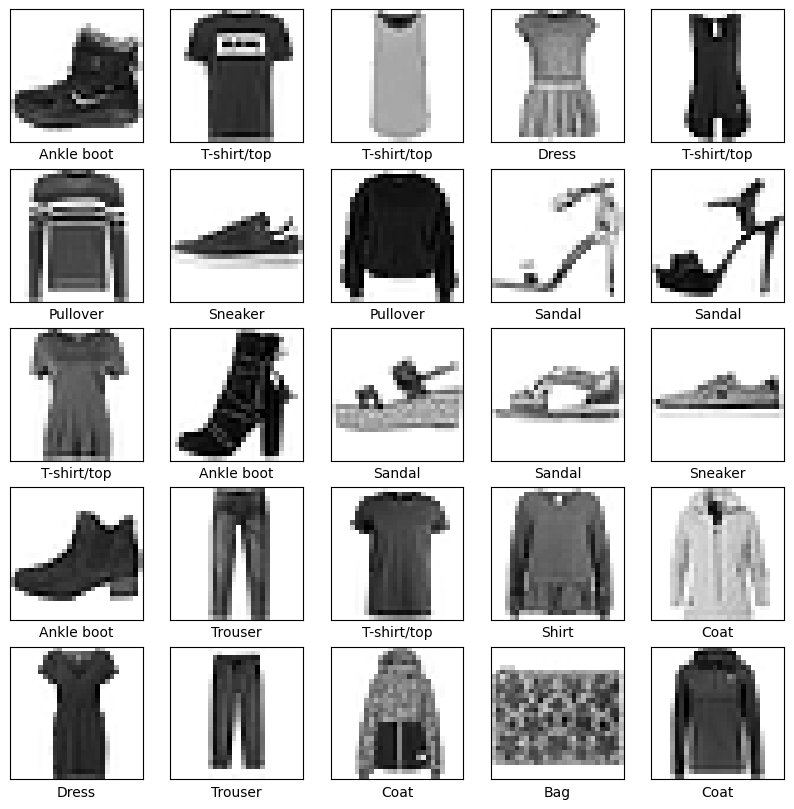

In [8]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[trainY[i]])
    
plt.show()

In [9]:
model = tf.keras.models.Sequential([
    
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3),
                           input_shape=(28, 28, 1),
                           activation='relu'),
    
    tf.keras.layers.AveragePooling2D(pool_size=(2, 2),
                                     name='pooling_layer_1'),
    
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3),
                           activation='relu',
                           padding='same'),
    
    tf.keras.layers.AveragePooling2D(pool_size=(2, 2),
                                     name='pooling_layer_2'),
    
    tf.keras.layers.GlobalAveragePooling2D(name='pooling_layer_3'),
    
    tf.keras.layers.Dense(len(class_names),
                          activation='softmax',
                          name='output_layer')
    ])

In [10]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [11]:
history = model.fit(train_norm, trainY_cat,
                    epochs=5,
                    validation_data=(test_norm, testY_cat))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.6047 - loss: 1.1113 - val_accuracy: 0.6777 - val_loss: 0.8519
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7234 - loss: 0.7786 - val_accuracy: 0.7133 - val_loss: 0.7672
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7507 - loss: 0.7059 - val_accuracy: 0.7676 - val_loss: 0.6836
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7708 - loss: 0.6540 - val_accuracy: 0.7819 - val_loss: 0.6303
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7840 - loss: 0.6139 - val_accuracy: 0.7730 - val_loss: 0.6276


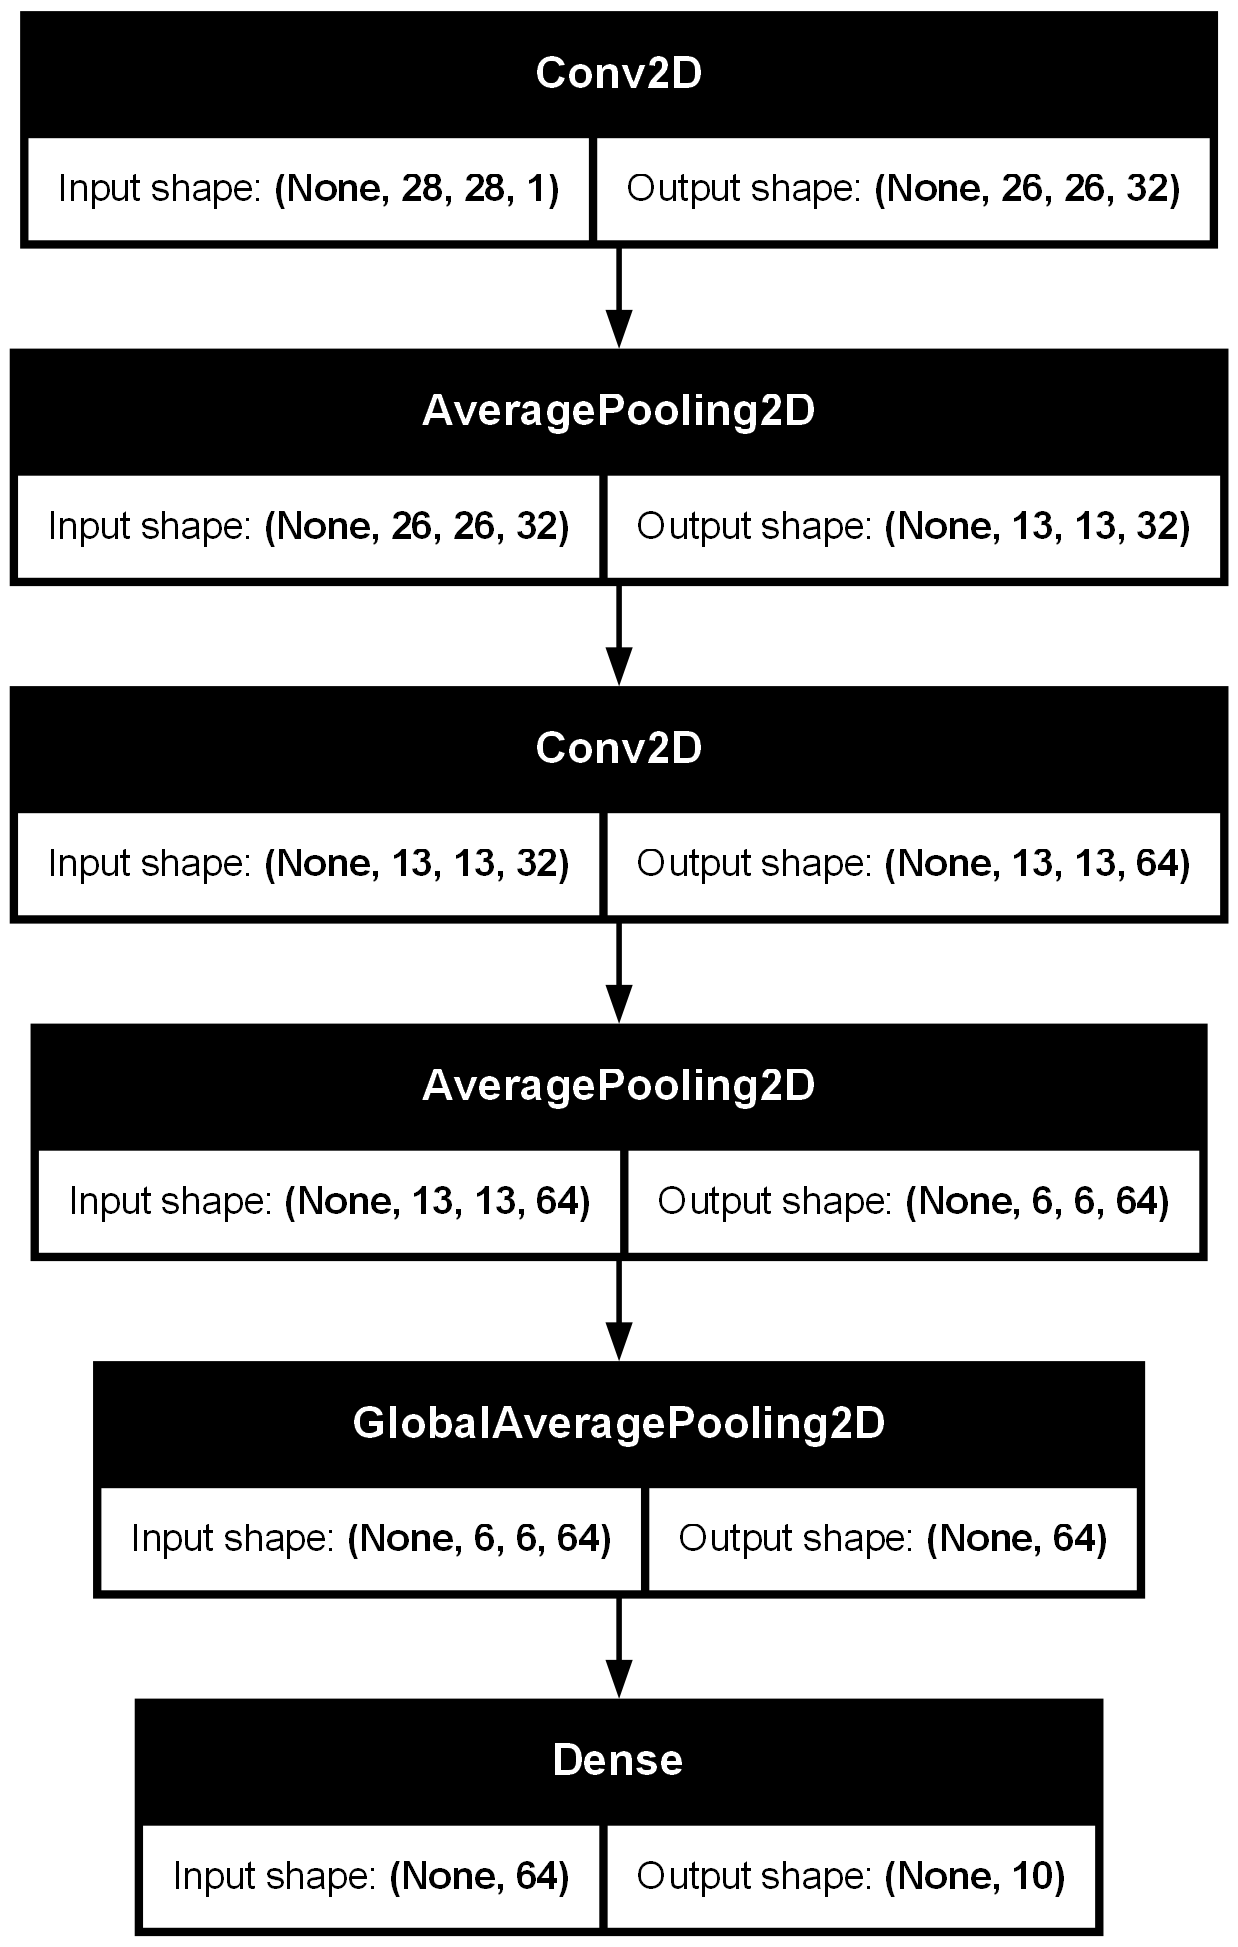

In [12]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pooling_layer_1 (AveragePooling2D)   │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pooling_layer_2 (AveragePooling2D)   │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pooling_layer_3                      │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,400 (228.13 KB)

 Trainable params: 19,466 (76.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,934 (152.09 KB)

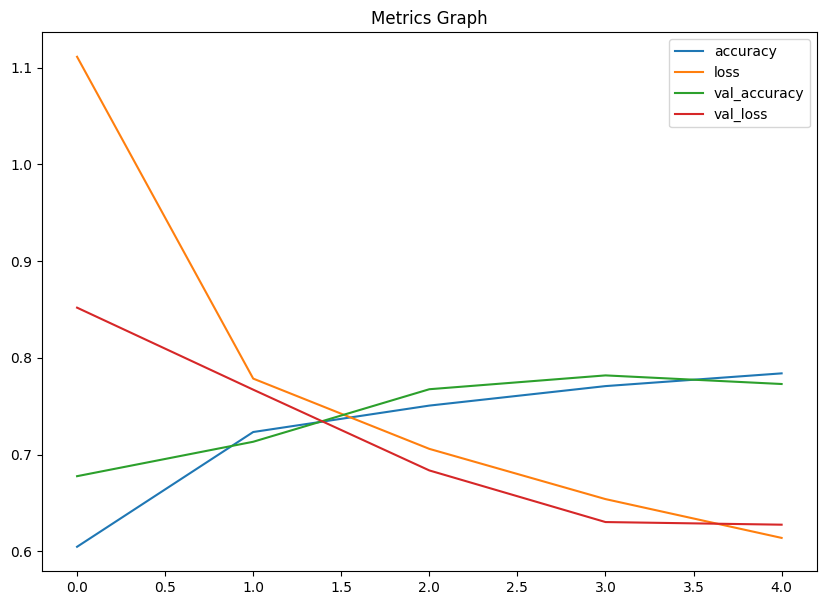

In [14]:
pd.DataFrame(history.history).plot(figsize=(10, 7))
plt.title("Metrics Graph")
plt.show()

In [15]:
model.evaluate(test_norm, testY_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7730 - loss: 0.6276


[0.6275610327720642, 0.7730000019073486]

In [16]:
predictions = model.predict(test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [17]:
predicted_labels = tf.argmax(predictions, axis=1)

In [18]:
y_test = tf.argmax(testY_cat, axis=1)

In [19]:
y_test = tf.Variable(y_test)

In [20]:
print(metrics.accuracy_score(y_test, predicted_labels))

0.773


In [21]:
print(metrics.classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.71      0.78      0.74      1000
           1       0.84      0.96      0.90      1000
           2       0.68      0.66      0.67      1000
           3       0.79      0.66      0.72      1000
           4       0.70      0.48      0.57      1000
           5       0.97      0.86      0.91      1000
           6       0.43      0.56      0.49      1000
           7       0.84      0.94      0.89      1000
           8       0.95      0.93      0.94      1000
           9       0.91      0.91      0.91      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000



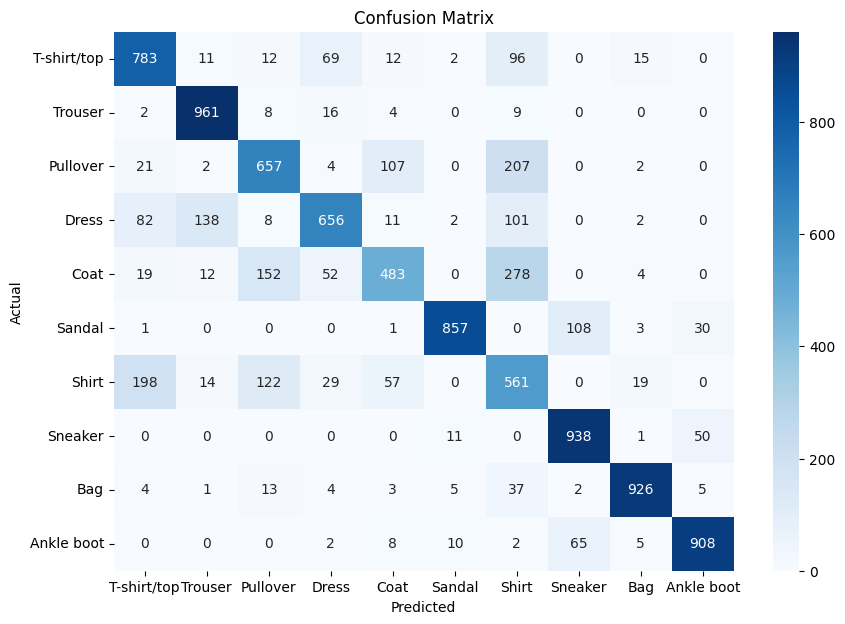

In [23]:
cm = metrics.confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()